<center><h1><span style="color: green;">THỰC HÀNH BUỔI 8.1</span></h1></center>

## MÔ HÌNH ANN (MULTI LAYER PERCEPTRON CLASSIFIER VÀ ỨNG DỤNG PCA)


# Ví dụ 1

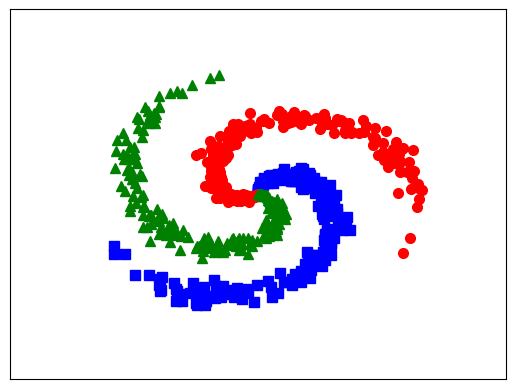

In [15]:
# import the necessary libraries
from __future__ import division, print_function, unicode_literals
import math
import numpy as np
import matplotlib.pyplot as plt

N = 200 # number of points per class
d = 2 # dimensionality
C = 3 # number of classes
X = np.zeros((d, N*C)) # data matrix (each row = single example)
y = np.zeros(N*C, dtype='uint8') # class labels
for j in range(C):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[:,ix] = np.c_[r*np.sin(t), r*np.cos(t)].T
  y[ix] = j

# lets visualize the data:
plt.plot(X[0, :N], X[1, :N], 'bs', markersize = 7);
plt.plot(X[0, N:2*N], X[1, N:2*N], 'ro', markersize = 7);
plt.plot(X[0, 2*N:], X[1, 2*N:], 'g^', markersize = 7);
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])
plt.savefig('example_points.png', bbox_inches='tight', dpi = 600)
plt.show()


_Do ở đây dữ liệu không tách được tuyến tính, nên chúng ta không thể sử dụng phương pháp hồi quy Softmax. Dưới đây chúng ta sử dụng một kiến trúc mạng ANN với 01 tầng ẩn bổ sung (tức số Layer L = 2), và ở tầng đầu ra (output) chúng ta sử dụng hàm kích hoạt là SoftMax, do đây là bài toán phân loại nhiều lớp._

Xây dựng các hàm cơ sở như Softmax

In [16]:
def softmax(V):
    e_V = np.exp(V - np.max(V, axis = 0, keepdims = True))
    Z = e_V / e_V.sum(axis = 0)
    return Z

Xây dựng hàm tổn thất như sau:

In [17]:
# cost or loss function
def cost(Y, Yhat):
    return -np.sum(Y*np.log(Yhat))/Y.shape[1]  

_Tiếp theo, chúng ta chuyển đầu ra Y từ dạng số nguyên trong tập {1, 2, …, C} - ứng với C classes – sang dạng onehot-coding, tức là vector C thành phần, nếu Y thuộc lớp thứ c thì tọa độ thứ c tương ứng là 1, các tọa độ khác là 0:_

In [18]:
## One-hot coding
from scipy import sparse
def convert_labels(y, C = 3):
    Y = sparse.coo_matrix((np.ones_like(y),
    (y, np.arange(len(y)))), shape = (C, len(y))).toarray()
    return Y

_Ở tầng đầu ra, chúng ta cần vector 03 thành phần là xác suất để điểm tương ứng rơi vào một trong các lớp 0, 1, 2 (thay cho 1, 2, 3). Vậy số chiều của các tầng trong mạng ANN sẽ là: d0 = 2 (tầng input); d1 = 100 (tầng hidden) và d2 = 3 (tầng output). Đoạn lệnh khởi tạo như sau:_

In [19]:
d0 = 2
d1 = h = 100 # size of hidden layer
d2 = C = 3

# initialize parameters randomly
W1 = 0.01*np.random.randn(d0, d1)
b1 = np.zeros((d1, 1))
W2 = 0.01*np.random.randn(d1, d2)
b2 = np.zeros((d2, 1))
Y = convert_labels(y, C)
N = X.shape[1]
eta = 1 # learning rate

Gradient Descent

In [20]:

for i in range(10000):
    ## Feedforward
    Z1 = np.dot(W1.T, X) + b1
    A1 = np.maximum(Z1, 0)
    Z2 = np.dot(W2.T, A1) + b2
    Yhat = softmax(Z2)
    
    # print loss after each 1000 iterations
    if i %1000 == 0:
        # compute the loss: average cross-entropy loss
        loss = cost(Y, Yhat)
        print("iter %d, loss: %f" %(i, loss))
        
    # backpropagation
    E2 = (Yhat - Y )/N
    dW2 = np.dot(A1, E2.T)
    db2 = np.sum(E2, axis = 1, keepdims = True)
    E1 = np.dot(W2, E2)
    E1[Z1 <= 0] = 0 # gradient of ReLU
    dW1 = np.dot(X, E1.T)
    db1 = np.sum(E1, axis = 1, keepdims = True)
    
    # Gradient Descent update
    W1 += -eta*dW1
    b1 += -eta*db1
    W2 += -eta*dW2
    b2 += -eta*db2

iter 0, loss: 1.098788
iter 1000, loss: 0.095974
iter 2000, loss: 0.041395
iter 3000, loss: 0.030092
iter 4000, loss: 0.024865
iter 5000, loss: 0.021750
iter 6000, loss: 0.019611
iter 7000, loss: 0.018092
iter 8000, loss: 0.016947
iter 9000, loss: 0.016028


Tính độ chính xác cho trường hợp áp dụng lên chính dữ liệu training

In [21]:
Z1 = np.dot(W1.T, X) + b1
A1 = np.maximum(Z1, 0)
Z2 = np.dot(W2.T, A1) + b2
predicted_class = np.argmax(Z2, axis=0)
acc = 100*np.mean(predicted_class == y)
print('training accuracy: %.2f %%' % (acc))

training accuracy: 99.67 %


Đoạn chương trình dưới đây thực hiện việc vẽ dữ liệu cùng với đường phân cách để ta có thể quan sát kết quả một cách trực quan:

(1, 14400)
100


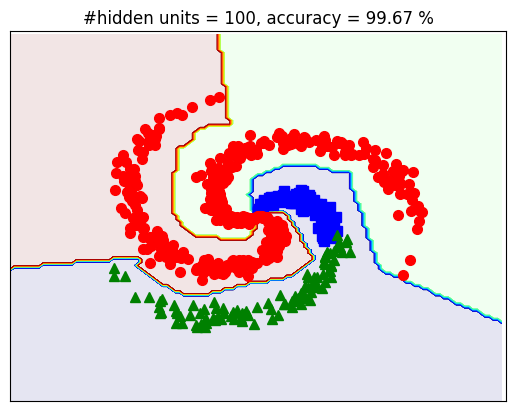

In [22]:
# Visualize results

xm = np.arange(-1.5, 1.5, 0.025)
xlen = len(xm)
ym = np.arange(-1.5, 1.5, 0.025)
ylen = len(ym)
xx, yy = np.meshgrid(xm, ym)

# xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
# xx.ravel(), yy.ravel()

print(np.ones((1, xx.size)).shape)
xx1 = xx.ravel().reshape(1, xx.size)
yy1 = yy.ravel().reshape(1, yy.size)

# print(xx.shape, yy.shape)
# XX = np.concatenate((np.ones((1, xx.size)), xx1, yy1), axis = 0)

X0 = np.vstack((xx1, yy1))

# print(X.shape)

Z1 = np.dot(W1.T, X0) + b1
A1 = np.maximum(Z1, 0)
Z2 = np.dot(W2.T, A1) + b2
# predicted class 
Z = np.argmax(Z2, axis=0)

Z = Z.reshape(xx.shape)
CS = plt.contourf(xx, yy, Z, 200, cmap='jet', alpha = .1)

# Plot also the training points
# plt.scatter(X[:, 1], X[:, 2], c=Y, edgecolors='k', cmap=plt.cm.Paired)
# plt.xlabel('Sepal length')
# plt.ylabel('Sepal width')
# X = X.T
N = 100
print(N)
plt.plot(X[0, :N], X[1, :N], 'bs', markersize = 7);
plt.plot(X[0, N:2*N], X[1, N:2*N], 'g^', markersize = 7);
plt.plot(X[0, 2*N:], X[1, 2*N:], 'ro', markersize = 7);
# plt.axis('off')
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.xticks(())
plt.yticks(())
plt.title('#hidden units = %d, accuracy = %.2f %%' %(d1, acc))
# plt.axis('equal')
# display(X[1:, :], original_label)
fn = 'ex_res'+ str(d1) + '.png'
# plt.savefig(fn, bbox_inches='tight', dpi = 600)
plt.show()


## Bài tập ứng dụng 1

In [23]:
# Import thư viện cần thiết
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import numpy as np
import matplotlib.pyplot as plt
import time

# Tải dữ liệu Iris
iris = load_iris()
X_full, y_full = iris.data.T, iris.target  # Chuyển X thành dạng (features, samples)

# Lấy 40 mẫu training và 10 mẫu validation cho mỗi lớp
N_train, N_val = 40, 10
X_train, y_train = np.zeros((4, N_train*3)), np.zeros(N_train*3, dtype='uint8')
X_val, y_val = np.zeros((4, N_val*3)), np.zeros(N_val*3, dtype='uint8')
for c in range(3):
    idx = np.where(y_full == c)[0]
    np.random.shuffle(idx)
    train_idx, val_idx = idx[:N_train], idx[N_train:N_train+N_val]
    X_train[:, c*N_train:(c+1)*N_train] = X_full[:, train_idx]
    y_train[c*N_train:(c+1)*N_train] = y_full[train_idx]
    X_val[:, c*N_val:(c+1)*N_val] = X_full[:, val_idx]
    y_val[c*N_val:(c+1)*N_val] = y_full[val_idx]

In [24]:
# Hàm chuyển nhãn sang one-hot coding
def convert_labels(y, C=3):
    Y = np.zeros((C, len(y)))
    for i in range(len(y)):
        Y[y[i], i] = 1
    return Y

# Hàm softmax
def softmax(V):
    e_V = np.exp(V - np.max(V, axis=0, keepdims=True))
    return e_V / e_V.sum(axis=0)

# Hàm tính loss
def cost(Y, Yhat):
    return -np.sum(Y * np.log(Yhat + 1e-9)) / Y.shape[1]

Mô hình ANN

In [25]:
# Huấn luyện và đánh giá ANN
def train_ann(X_train, y_train, X_val, y_val, h=100):
    d0, d2 = 4, 3  # Input: 4 features, Output: 3 classes
    W1 = 0.01 * np.random.randn(d0, h)
    b1 = np.zeros((h, 1))
    W2 = 0.01 * np.random.randn(h, d2)
    b2 = np.zeros((d2, 1))
    Y = convert_labels(y_train)
    eta = 0.1
    start_time = time.time()
    for i in range(5000):
        Z1 = np.dot(W1.T, X_train) + b1
        A1 = np.maximum(Z1, 0)  # ReLU
        Z2 = np.dot(W2.T, A1) + b2
        Yhat = softmax(Z2)
        if i % 1000 == 0:
            loss = cost(Y, Yhat)
            print(f"ANN iter {i}, loss: {loss:.4f}")
        E2 = (Yhat - Y) / X_train.shape[1]
        dW2 = np.dot(A1, E2.T)
        db2 = np.sum(E2, axis=1, keepdims=True)
        E1 = np.dot(W2, E2)
        E1[Z1 <= 0] = 0
        dW1 = np.dot(X_train, E1.T)
        db1 = np.sum(E1, axis=1, keepdims=True)
        W1 -= eta * dW1
        b1 -= eta * db1
        W2 -= eta * dW2
        b2 -= eta * db2
    train_time = time.time() - start_time

    # Dự đoán
    def predict(X):
        Z1 = np.dot(W1.T, X) + b1
        A1 = np.maximum(Z1, 0)
        Z2 = np.dot(W2.T, A1) + b2
        return np.argmax(Z2, axis=0)

    start_time = time.time()
    y_train_pred = predict(X_train)
    y_val_pred = predict(X_val)
    predict_time = (time.time() - start_time) / (X_train.shape[1] + X_val.shape[1])

    # Đánh giá
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_val = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred, average='macro')
    rec = recall_score(y_val, y_val_pred, average='macro')
    cm = confusion_matrix(y_val, y_val_pred)
    return acc_train, acc_val, prec, rec, cm, train_time, predict_time, predict


Kết quả ANN với h=100:
ANN iter 0, loss: 1.0988
ANN iter 1000, loss: 0.0749
ANN iter 2000, loss: 0.0548
ANN iter 3000, loss: 0.0468
ANN iter 4000, loss: 0.0422
Accuracy Train: 0.9833, Validation: 0.9667
Precision: 0.9697, Recall: 0.9667
Thời gian train: 0.3720s, Thời gian predict: 0.000000s


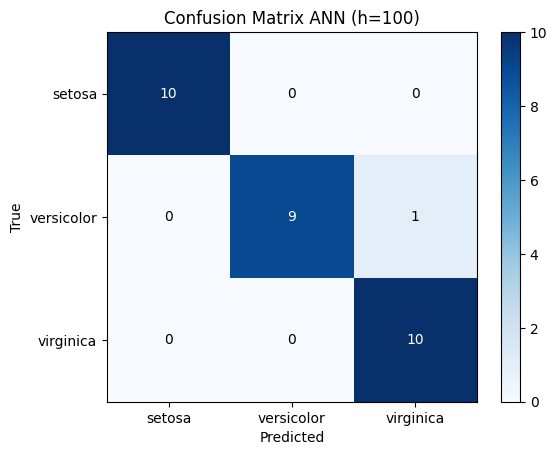


Kết quả ANN với h=75:
ANN iter 0, loss: 1.0989
ANN iter 1000, loss: 0.0761
ANN iter 2000, loss: 0.0554
ANN iter 3000, loss: 0.0471
ANN iter 4000, loss: 0.0423
Accuracy Train: 0.9833, Validation: 0.9667
Precision: 0.9697, Recall: 0.9667
Thời gian train: 0.3265s, Thời gian predict: 0.000000s


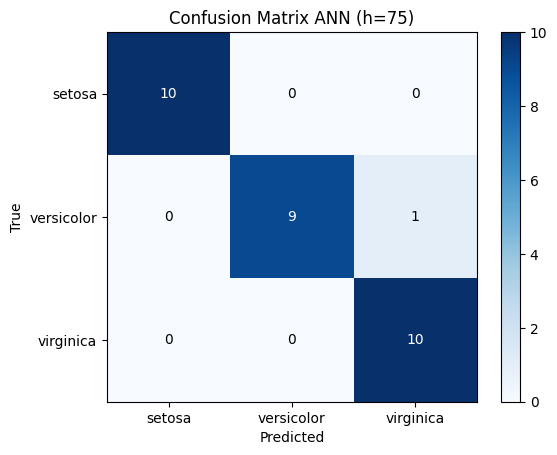


Kết quả ANN với h=50:
ANN iter 0, loss: 1.0990
ANN iter 1000, loss: 0.0752
ANN iter 2000, loss: 0.0551
ANN iter 3000, loss: 0.0469
ANN iter 4000, loss: 0.0423
Accuracy Train: 0.9833, Validation: 0.9667
Precision: 0.9697, Recall: 0.9667
Thời gian train: 0.2805s, Thời gian predict: 0.000000s


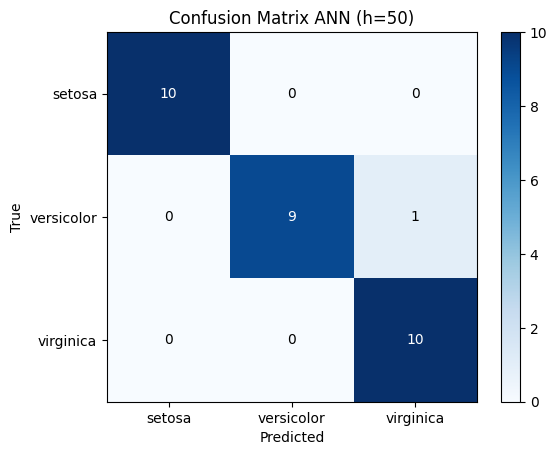

In [26]:
# Thực nghiệm với ANN (h=100, 75, 50)
for h in [100, 75, 50]:
    print(f"\nKết quả ANN với h={h}:")
    acc_train, acc_val, prec, rec, cm, train_time, predict_time, _ = train_ann(X_train, y_train, X_val, y_val, h)
    print(f"Accuracy Train: {acc_train:.4f}, Validation: {acc_val:.4f}")
    print(f"Precision: {prec:.4f}, Recall: {rec:.4f}")
    print(f"Thời gian train: {train_time:.4f}s, Thời gian predict: {predict_time:.6f}s")
    
    # Sửa đoạn code vẽ confusion matrix để thêm số
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix ANN (h={h})')
    plt.colorbar()
    plt.xticks([0, 1, 2], iris.target_names)
    plt.yticks([0, 1, 2], iris.target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')

    # Thêm số vào từng ô
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'), 
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

    plt.show()

SoftMax Regression

In [27]:
# Huấn luyện và đánh giá SoftMax Regression
def train_softmax(X_train, y_train, X_val, y_val):
    model = LogisticRegression(multi_class='multinomial', max_iter=1000)
    start_time = time.time()
    model.fit(X_train.T, y_train)  # Chuyển X về dạng (samples, features)
    train_time = time.time() - start_time
    start_time = time.time()
    y_train_pred = model.predict(X_train.T)
    y_val_pred = model.predict(X_val.T)
    predict_time = (time.time() - start_time) / (X_train.shape[1] + X_val.shape[1])
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_val = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred, average='macro')
    rec = recall_score(y_val, y_val_pred, average='macro')
    cm = confusion_matrix(y_val, y_val_pred)
    return acc_train, acc_val, prec, rec, cm, train_time, predict_time


Kết quả SoftMax Regression:
Accuracy Train: 0.9833, Validation: 0.9667
Precision: 0.9697, Recall: 0.9667
Thời gian train: 0.0863s, Thời gian predict: 0.000002s


c:\Users\TIEN DAT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


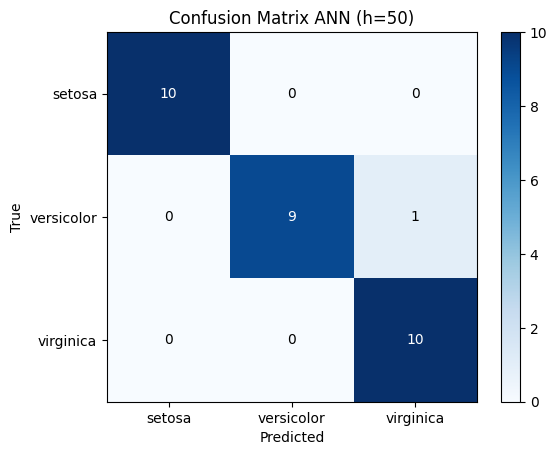

In [28]:
# Thực nghiệm với SoftMax Regression
print("\nKết quả SoftMax Regression:")
acc_train_sm, acc_val_sm, prec_sm, rec_sm, cm_sm, train_time_sm, predict_time_sm = train_softmax(X_train, y_train, X_val, y_val)
print(f"Accuracy Train: {acc_train_sm:.4f}, Validation: {acc_val_sm:.4f}")
print(f"Precision: {prec_sm:.4f}, Recall: {rec_sm:.4f}")
print(f"Thời gian train: {train_time_sm:.4f}s, Thời gian predict: {predict_time_sm:.6f}s")
# Sửa đoạn code vẽ confusion matrix để thêm số
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix ANN (h={h})')
plt.colorbar()
plt.xticks([0, 1, 2], iris.target_names)
plt.yticks([0, 1, 2], iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')

# Thêm số vào từng ô
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), 
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.show()

Naïve Bayes

In [29]:
# Huấn luyện và đánh giá Naïve Bayes
def train_nb(X_train, y_train, X_val, y_val):
    model = GaussianNB()
    start_time = time.time()
    model.fit(X_train.T, y_train)
    train_time = time.time() - start_time
    start_time = time.time()
    y_train_pred = model.predict(X_train.T)
    y_val_pred = model.predict(X_val.T)
    predict_time = (time.time() - start_time) / (X_train.shape[1] + X_val.shape[1])
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_val = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred, average='macro')
    rec = recall_score(y_val, y_val_pred, average='macro')
    cm = confusion_matrix(y_val, y_val_pred)
    return acc_train, acc_val, prec, rec, cm, train_time, predict_time


Kết quả Naïve Bayes:
Accuracy Train: 0.9500, Validation: 1.0000
Precision: 1.0000, Recall: 1.0000
Thời gian train: 0.0014s, Thời gian predict: 0.000004s


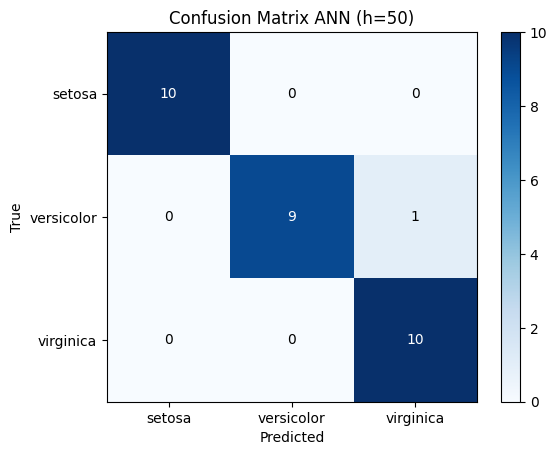

In [30]:
# Thực nghiệm với Naïve Bayes
print("\nKết quả Naïve Bayes:")
acc_train_nb, acc_val_nb, prec_nb, rec_nb, cm_nb, train_time_nb, predict_time_nb = train_nb(X_train, y_train, X_val, y_val)
print(f"Accuracy Train: {acc_train_nb:.4f}, Validation: {acc_val_nb:.4f}")
print(f"Precision: {prec_nb:.4f}, Recall: {rec_nb:.4f}")
print(f"Thời gian train: {train_time_nb:.4f}s, Thời gian predict: {predict_time_nb:.6f}s")
# Sửa đoạn code vẽ confusion matrix để thêm số
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix ANN (h={h})')
plt.colorbar()
plt.xticks([0, 1, 2], iris.target_names)
plt.yticks([0, 1, 2], iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')

# Thêm số vào từng ô
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), 
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.show()

**Nhận xét:**
- Khi giảm số chiều layer ẩn (100 -> 75 -> 50), độ chính xác trên tập validation có thể giảm do mô hình mất khả năng học các đặc trưng phức tạp.
- Thời gian huấn luyện và dự đoán giảm khi số chiều layer ẩn giảm, do ít tham số hơn cần tính toán.
- So với SoftMax và Naïve Bayes, ANN thường có thời gian train lâu hơn nhưng có thể đạt độ chính xác cao hơn nếu điều chỉnh tốt.
- SoftMax và Naïve Bayes nhanh hơn về thời gian train/predict, nhưng độ chính xác phụ thuộc vào tính tuyến tính của dữ liệu.

# Ví dụ 2

In [31]:
import os
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# set names to the paths because they're too long
data_path = 'handwritting'
# train path
train_images_path = os.path.join(data_path, 'train-images-idx3-ubyte.gz')
train_labels_path = os.path.join(data_path, 'train-labels-idx1-ubyte.gz')
# test path
test_images_path = os.path.join(data_path, 't10k-images-idx3-ubyte.gz')
test_labels_path = os.path.join(data_path, 't10k-labels-idx1-ubyte.gz')

#### Đọc dữ liệu ảnh, lấy tập dữ liệu 5000 ảnh bất kỳ; giảm số chiều dữ liệu xuống còn 100 chiều (từ 28x28 = 784 chiều ban đầu).

In [32]:
def get_mnist_data(images_path, labels_path, num_images, shuffle=False, _is=True, image_size=28):
    """
    This shuffle param is active when .gz is downloaded at:
    - 'http://yann.lecun.com/exdb/mnist/'
    - This function return random num_images in 60000 or 10000
    """
    # read data
    import gzip # to decompress gz (zip) file
    # open file training to read training data
    f_images = gzip.open(images_path,'r')

    # skip 16 first bytes because these are not data, only header infor
    f_images.read(16)

    # general: read num_images data samples if this parameter is set;
    # if not, read all (60000 training or 10000 test)
    real_num = num_images if not shuffle else (60000 if _is else 10000)
    # read all data to buf_images (28x28xreal_num)
    buf_images = f_images.read(image_size * image_size * real_num)

    # images
    images = np.frombuffer(buf_images, dtype=np.uint8).astype(np.float32)
    images = images.reshape(real_num, image_size, image_size,)

    # Read labels
    f_labels = gzip.open(labels_path,'r')
    f_labels.read(8)

    labels = np.zeros((real_num)).astype(np.int64)

    # rearrange to correspond the images and labels
    for i in range(0, real_num):
        buf_labels = f_labels.read(1)
        labels[i] = np.frombuffer(buf_labels, dtype=np.uint8).astype(np.int64)

    # shuffle to get random images data
    if shuffle is True:
        rand_id = np.random.randint(real_num, size=num_images)

        images = images[rand_id, :]
        labels = labels[rand_id,]

    # change images data to type of vector 28x28 dimentional
    images = images.reshape(num_images, image_size * image_size)
    return images, labels

# Gọi phương thức đọc dữ liệu
train_images, train_labels = get_mnist_data(train_images_path, train_labels_path, 5000, shuffle=True)
test_images, test_labels = get_mnist_data(test_images_path, test_labels_path, 10000, _is=False, shuffle=True)

print("Kích thước ban đầu:")
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Kích thước ban đầu:
Train images shape: (5000, 784)
Train labels shape: (5000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


### (a) Giảm số chiều dữ liệu xuống còn 125 chiều (từ 28x28 = 784 chiều ban đầu) với tập dữ liệu 5000 ảnh bất kỳ.

In [33]:
# Giảm chiều dữ liệu xuống 125 chiều bằng PCA
pca = PCA(n_components=125)
train_images_pca = pca.fit_transform(train_images)  # Fit và transform trên tập train
test_images_pca = pca.transform(test_images)       # Chỉ transform trên tập test

# In kích thước sau khi giảm chiều
print("\nKích thước sau khi giảm chiều xuống 100:")
print("Train images PCA shape:", train_images_pca.shape)
print("Test images PCA shape:", test_images_pca.shape)

# In tỷ lệ phương sai giải thích
print("\nTỷ lệ phương sai giải thích bởi 100 thành phần chính:")
print(pca.explained_variance_ratio_)
print(f"Tổng tỷ lệ phương sai giải thích: {round(sum(pca.explained_variance_ratio_)*100,2)}%")


Kích thước sau khi giảm chiều xuống 100:
Train images PCA shape: (5000, 125)
Test images PCA shape: (10000, 125)

Tỷ lệ phương sai giải thích bởi 100 thành phần chính:
[0.0943283  0.07194943 0.06192309 0.05339632 0.04855273 0.04223474
 0.03278792 0.02902907 0.02783061 0.023615   0.02076494 0.02054529
 0.01756967 0.01748515 0.01578452 0.01480707 0.01353122 0.01311363
 0.0121189  0.0119896  0.01080802 0.01038402 0.00979639 0.00911557
 0.00906425 0.00858811 0.00804879 0.00767692 0.00751516 0.00723739
 0.00657747 0.00655444 0.00617603 0.00599139 0.00582485 0.00550209
 0.00523972 0.00513976 0.00486503 0.00473799 0.00459775 0.00445344
 0.00420776 0.0041243  0.00390564 0.0037059  0.00361226 0.0035764
 0.00342169 0.00336821 0.00327245 0.00313926 0.00304759 0.00289574
 0.00279685 0.00274736 0.00260554 0.00254359 0.0025205  0.00246421
 0.00246017 0.002344   0.00227613 0.00223112 0.00217409 0.00207623
 0.00202176 0.00200372 0.00193478 0.00189919 0.00184531 0.00181071
 0.00178922 0.00175534 0.001

### (b) Áp dụng các phương pháp phân loại nhiều lớp: Multinomial Logistic Regression và ANN để phân loại cho tập dữ liệu giảm chiều nói trên, tỷ lệ train:test là 0.7:0.3.

In [34]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time

# Split data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(train_images_pca, train_labels, 
                                                    test_size=0.3, random_state=42)

# b. Multinomial Logistic Regression
start_time = time.time()
log_reg = LogisticRegression(multi_class='multinomial', max_iter=1000)
log_reg.fit(X_train, y_train)
log_reg_time = time.time() - start_time
log_reg_train_pred = log_reg.predict(X_train)
log_reg_test_pred = log_reg.predict(X_test)
log_reg_train_acc = accuracy_score(y_train, log_reg_train_pred)
log_reg_test_acc = accuracy_score(y_test, log_reg_test_pred)
log_reg_train_prec = precision_score(y_train, log_reg_train_pred, average='macro')
log_reg_test_prec = precision_score(y_test, log_reg_test_pred, average='macro')
log_reg_train_rec = recall_score(y_train, log_reg_train_pred, average='macro')
log_reg_test_rec = recall_score(y_test, log_reg_test_pred, average='macro')
log_reg_cm = confusion_matrix(y_test, log_reg_test_pred)

print("Logistic Regression:")
print(f"Train - Acc: {log_reg_train_acc}, Prec: {log_reg_train_prec}, Rec: {log_reg_train_rec}")
print(f"Test - Acc: {log_reg_test_acc}, Prec: {log_reg_test_prec}, Rec: {log_reg_test_rec}")

# b. ANN (MLP)
start_time = time.time()
ann = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
ann.fit(X_train, y_train)
ann_time = time.time() - start_time
ann_train_pred = ann.predict(X_train)
ann_test_pred = ann.predict(X_test)
ann_train_acc = accuracy_score(y_train, ann_train_pred)
ann_test_acc = accuracy_score(y_test, ann_test_pred)
ann_train_prec = precision_score(y_train, ann_train_pred, average='macro')
ann_test_prec = precision_score(y_test, ann_test_pred, average='macro')
ann_train_rec = recall_score(y_train, ann_train_pred, average='macro')
ann_test_rec = recall_score(y_test, ann_test_pred, average='macro')
ann_cm = confusion_matrix(y_test, ann_test_pred)

print("ANN (100):")
print(f"Train - Acc: {ann_train_acc}, Prec: {ann_train_prec}, Rec: {ann_train_rec}")
print(f"Test - Acc: {ann_test_acc}, Prec: {ann_test_prec}, Rec: {ann_test_rec}")

Logistic Regression:
Train - Acc: 1.0, Prec: 1.0, Rec: 1.0
Test - Acc: 0.814, Prec: 0.8131988002050253, Rec: 0.814276756159137
ANN (100):
Train - Acc: 1.0, Prec: 1.0, Rec: 1.0
Test - Acc: 0.8406666666666667, Prec: 0.8424510230918993, Rec: 0.8407428848631294


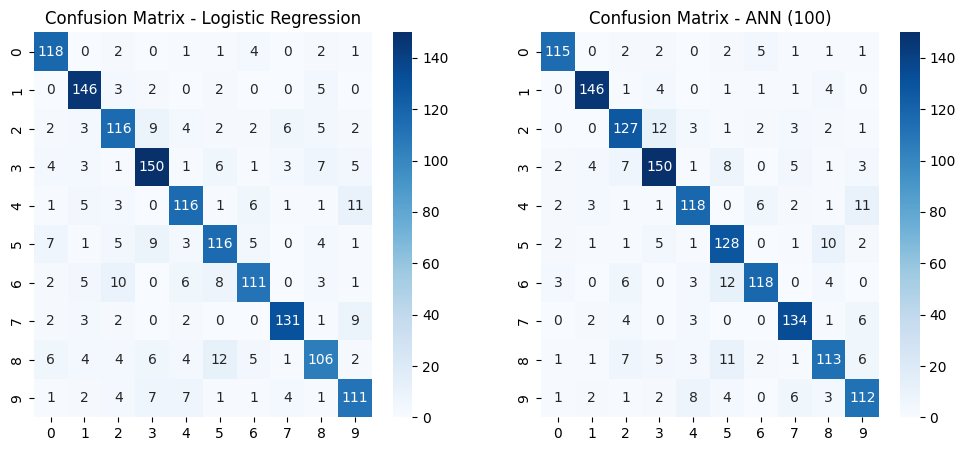

In [35]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(log_reg_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.subplot(1, 2, 2)
sns.heatmap(ann_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ANN (100)')
plt.show()

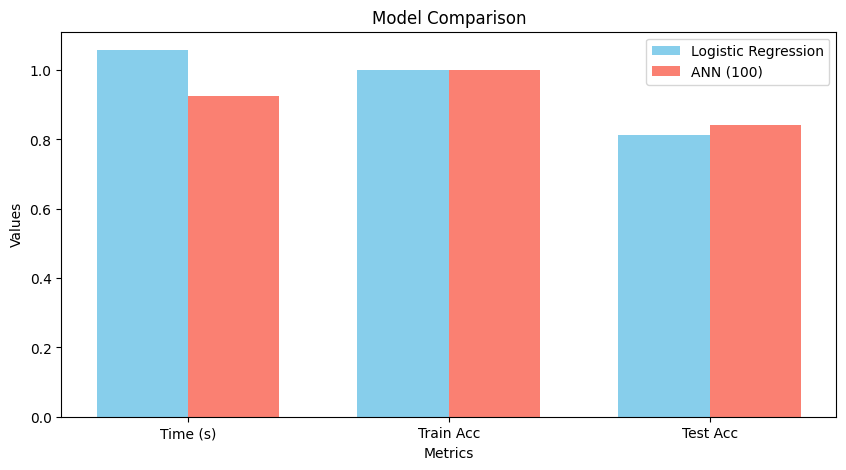

In [36]:
# c. Visualize comparison
metrics = ['Time (s)', 'Train Acc', 'Test Acc']
log_reg_values = [log_reg_time, log_reg_train_acc, log_reg_test_acc]
ann_values = [ann_time, ann_train_acc, ann_test_acc]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, log_reg_values, width, label='Logistic Regression', color='skyblue')
plt.bar(x + width/2, ann_values, width, label='ANN (100)', color='salmon')
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.xticks(x, metrics)
plt.legend()
plt.title('Model Comparison')
plt.show()

In [37]:
# d. ANN with 150 hidden units
start_time = time.time()
ann_150 = MLPClassifier(hidden_layer_sizes=(150,), max_iter=500)
ann_150.fit(X_train, y_train)
ann_150_time = time.time() - start_time
ann_150_train_pred = ann_150.predict(X_train)
ann_150_test_pred = ann_150.predict(X_test)
ann_150_train_acc = accuracy_score(y_train, ann_150_train_pred)
ann_150_test_acc = accuracy_score(y_test, ann_150_test_pred)

print("ANN (150) - Time:", ann_150_time, "s, Train Acc:", ann_150_train_acc, 
      "Test Acc:", ann_150_test_acc)

ANN (150) - Time: 1.2079575061798096 s, Train Acc: 1.0 Test Acc: 0.836


## Ví dụ 3

In [38]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv('Dry_Bean_Dataset.csv')
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Labels

(a) Giảm dữ liệu xuống còn 2 hoặc 3 chiều, hiển thị trực quan dữ liệu để có thể quan sát phân bố của các loại hạt khác nhau.

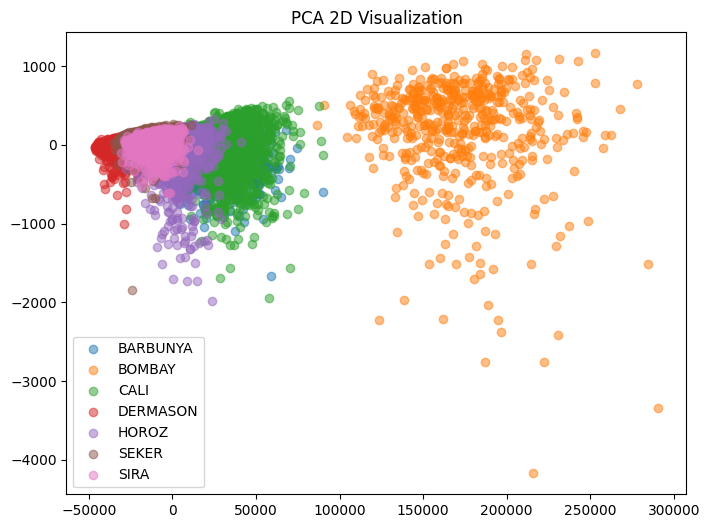

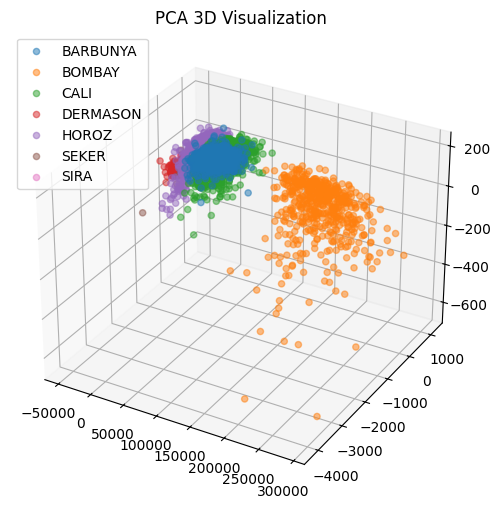

In [39]:
# (a) PCA to 2D and 3D, visualize
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X)
plt.figure(figsize=(8, 6))
for label in np.unique(y):
    plt.scatter(X_2d[y == label, 0], X_2d[y == label, 1], label=label, alpha=0.5)
plt.title('PCA 2D Visualization')
plt.legend()
plt.show()

pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
for label in np.unique(y):
    ax.scatter(X_3d[y == label, 0], X_3d[y == label, 1], X_3d[y == label, 2], label=label, alpha=0.5)
ax.set_title('PCA 3D Visualization')
ax.legend()
plt.show()

(b) Lấy dữ liệu gốc, thực hiện chia dữ liệu thành tập train:validion với tỉ lệ 7:3, sau đó

In [40]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

a. Phân loại bằng phương pháp Naïve Bayes phù hợp. Đánh giá độ chính xác của mô hình trên
các độ đo Precision, Recall và Accuracy. Giải thích kết quả

Naïve Bayes - Train Acc: 0.7656135194709772 Prec: 0.7714789830624557 Rec: 0.7677542162312906
Naïve Bayes - Val Acc: 0.7627326150832517 Prec: 0.7681969291661278 Rec: 0.7653776479998632


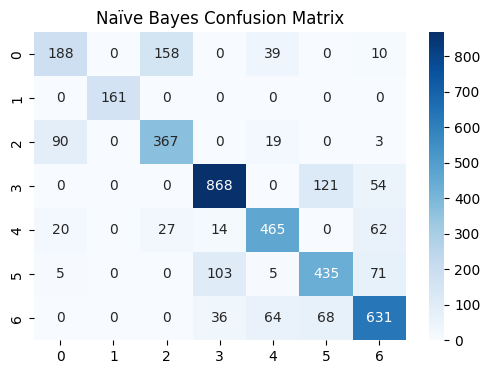

In [41]:
# Naïve Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_train_pred = nb.predict(X_train)
nb_val_pred = nb.predict(X_val)
nb_train_acc = accuracy_score(y_train, nb_train_pred)
nb_val_acc = accuracy_score(y_val, nb_val_pred)
nb_train_prec = precision_score(y_train, nb_train_pred, average='macro')
nb_val_prec = precision_score(y_val, nb_val_pred, average='macro')
nb_train_rec = recall_score(y_train, nb_train_pred, average='macro')
nb_val_rec = recall_score(y_val, nb_val_pred, average='macro')
nb_cm = confusion_matrix(y_val, nb_val_pred)
print("Naïve Bayes - Train Acc:", nb_train_acc, "Prec:", nb_train_prec, "Rec:", nb_train_rec)
print("Naïve Bayes - Val Acc:", nb_val_acc, "Prec:", nb_val_prec, "Rec:", nb_val_rec)
plt.figure(figsize=(6, 4))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Naïve Bayes Confusion Matrix')
plt.show()

=> Naïve Bayes giả định tính độc lập của tính năng, nhanh nhưng có thể hoạt động kém hiệu quả do giả định này.

b. Phân loại bằng phương pháp Multinomial Logistic Regression. Đánh giá độ chính xác của mô hình trên các độ đo Precision, Recall và Accuracy. Giải thích kết quả và ý nghĩa của các hệ số thu được từ mô hình.

Logistic Regression - Train Acc: 0.8548336307337042 Prec: 0.8703191935044486 Rec: 0.8645309102282963
Logistic Regression - Val Acc: 0.8572477962781586 Prec: 0.8732877274077193 Rec: 0.8685082706442765


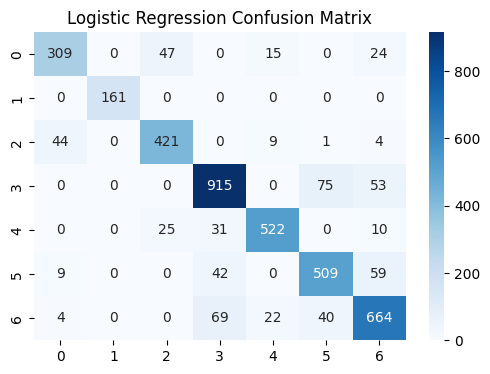

In [42]:
# Multinomial Logistic Regression
lr = LogisticRegression(multi_class='multinomial', max_iter=1000)
lr.fit(X_train, y_train)
lr_train_pred = lr.predict(X_train)
lr_val_pred = lr.predict(X_val)
lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_val_acc = accuracy_score(y_val, lr_val_pred)
lr_train_prec = precision_score(y_train, lr_train_pred, average='macro')
lr_val_prec = precision_score(y_val, lr_val_pred, average='macro')
lr_train_rec = recall_score(y_train, lr_train_pred, average='macro')
lr_val_rec = recall_score(y_val, lr_val_pred, average='macro')
lr_cm = confusion_matrix(y_val, lr_val_pred)
print("Logistic Regression - Train Acc:", lr_train_acc, "Prec:", lr_train_prec, "Rec:", lr_train_rec)
print("Logistic Regression - Val Acc:", lr_val_acc, "Prec:", lr_val_prec, "Rec:", lr_val_rec)
plt.figure(figsize=(6, 4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

=> Mô hình LR phân loại xác suất trực tiếp; hệ số chỉ ra tầm quan trọng của tính năng trên mỗi lớp.

c. Xây dựng một mô hình ANN với 01 tầng ẩn (ngoại trừ đầu vào và đầu ra), số chiều của tầng ẩn là 32, đầu ra sử dụng dạng hàm loss và phân loại phù hợp. Sử dụng mô hình này để phân loại dữ liệu nói trên. Đánh giá độ chính xác của mô hình trên các độ đo Precision, Recall và Accuracy. Giải thích kết quả

In [43]:
# ANN (corrected)
ann = MLPClassifier(hidden_layer_sizes=(32,), max_iter=500, solver='adam')  # Default log loss implicit
ann.fit(X_train, y_train)
ann_train_pred = ann.predict(X_train)
ann_val_pred = ann.predict(X_val)
ann_train_acc = accuracy_score(y_train, ann_train_pred)
ann_val_acc = accuracy_score(y_val, ann_val_pred)
ann_train_prec = precision_score(y_train, ann_train_pred, average='macro')
ann_val_prec = precision_score(y_val, ann_val_pred, average='macro')
ann_train_rec = recall_score(y_train, ann_train_pred, average='macro')
ann_val_rec = recall_score(y_val, ann_val_pred, average='macro')
print("ANN - Train Acc:", ann_train_acc, "Prec:", ann_train_prec, "Rec:", ann_train_rec)
print("ANN - Val Acc:", ann_val_acc, "Prec:", ann_val_prec, "Rec:", ann_val_rec)
# Explanation: ANN captures non-linear patterns, may overfit if not tuned.

ANN - Train Acc: 0.3236065917917498 Prec: 0.21184743285515978 Rec: 0.3107018141201136
ANN - Val Acc: 0.3190499510284035 Prec: 0.22551492970386214 Rec: 0.3117924367506991


(c) Giảm dữ liệu xuống còn 04 chiều, sau đó thực hiện lại tất cả các công việc trong ý (b). Hãy giải thích kết quả và cho biết mô hình nào bị ảnh hưởng nhiều nhất bởi việc giảm chiều dữ liệu.

Naïve Bayes 4D - Train Acc: 0.8939855148525244 Prec: 0.9048156853282893 Rec: 0.9091818359092966
Naïve Bayes 4D - Val Acc: 0.8964250734573947 Prec: 0.9058021999456304 Rec: 0.9107768396374658


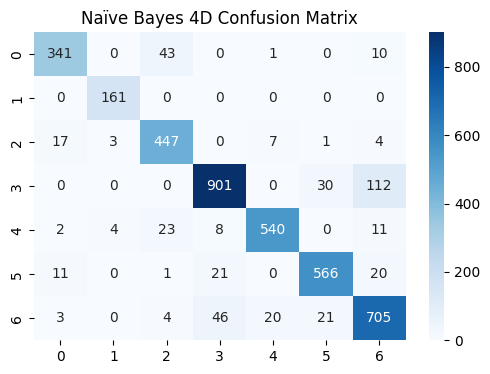

Logistic Regression 4D - Train Acc: 0.8831741366642175 Prec: 0.8956208512265308 Rec: 0.8955639574954567
Logistic Regression 4D - Val Acc: 0.8890793339862879 Prec: 0.9018773163938094 Rec: 0.9018456821448717


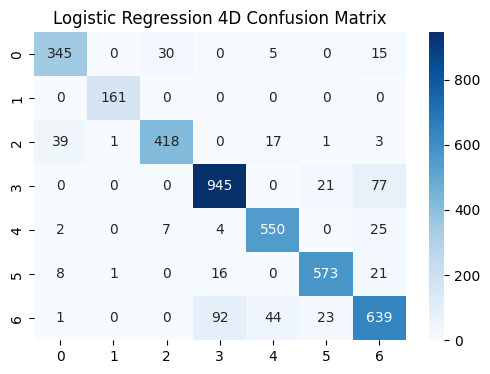

ANN 4D - Train Acc: 0.8544137713865855 Prec: 0.8734223636694305 Rec: 0.8682681890045562
ANN 4D - Val Acc: 0.8525954946131243 Prec: 0.8722731643601104 Rec: 0.866151042905404


In [44]:
# (c) PCA to 4D
pca_4d = PCA(n_components=4)
X_4d = pca_4d.fit_transform(X)
X_train_4d, X_val_4d, y_train, y_val = train_test_split(X_4d, y, test_size=0.3, random_state=42)

# Repeat for Naïve Bayes
nb.fit(X_train_4d, y_train)
nb_train_pred_4d = nb.predict(X_train_4d)
nb_val_pred_4d = nb.predict(X_val_4d)
nb_train_acc_4d = accuracy_score(y_train, nb_train_pred_4d)
nb_val_acc_4d = accuracy_score(y_val, nb_val_pred_4d)
nb_train_prec_4d = precision_score(y_train, nb_train_pred_4d, average='macro')
nb_val_prec_4d = precision_score(y_val, nb_val_pred_4d, average='macro')
nb_train_rec_4d = recall_score(y_train, nb_train_pred_4d, average='macro')
nb_val_rec_4d = recall_score(y_val, nb_val_pred_4d, average='macro')
nb_cm_4d = confusion_matrix(y_val, nb_val_pred_4d)
print("Naïve Bayes 4D - Train Acc:", nb_train_acc_4d, "Prec:", nb_train_prec_4d, "Rec:", nb_train_rec_4d)
print("Naïve Bayes 4D - Val Acc:", nb_val_acc_4d, "Prec:", nb_val_prec_4d, "Rec:", nb_val_rec_4d)
plt.figure(figsize=(6, 4))
sns.heatmap(nb_cm_4d, annot=True, fmt='d', cmap='Blues')
plt.title('Naïve Bayes 4D Confusion Matrix')
plt.show()

# Repeat for Logistic Regression
lr.fit(X_train_4d, y_train)
lr_train_pred_4d = lr.predict(X_train_4d)
lr_val_pred_4d = lr.predict(X_val_4d)
lr_train_acc_4d = accuracy_score(y_train, lr_train_pred_4d)
lr_val_acc_4d = accuracy_score(y_val, lr_val_pred_4d)
lr_train_prec_4d = precision_score(y_train, lr_train_pred_4d, average='macro')
lr_val_prec_4d = precision_score(y_val, lr_val_pred_4d, average='macro')
lr_train_rec_4d = recall_score(y_train, lr_train_pred_4d, average='macro')
lr_val_rec_4d = recall_score(y_val, lr_val_pred_4d, average='macro')
lr_cm_4d = confusion_matrix(y_val, lr_val_pred_4d)
print("Logistic Regression 4D - Train Acc:", lr_train_acc_4d, "Prec:", lr_train_prec_4d, "Rec:", lr_train_rec_4d)
print("Logistic Regression 4D - Val Acc:", lr_val_acc_4d, "Prec:", lr_val_prec_4d, "Rec:", lr_val_rec_4d)
plt.figure(figsize=(6, 4))
sns.heatmap(lr_cm_4d, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression 4D Confusion Matrix')
plt.show()

# Repeat for ANN
ann.fit(X_train_4d, y_train)
ann_train_pred_4d = ann.predict(X_train_4d)
ann_val_pred_4d = ann.predict(X_val_4d)
ann_train_acc_4d = accuracy_score(y_train, ann_train_pred_4d)
ann_val_acc_4d = accuracy_score(y_val, ann_val_pred_4d)
ann_train_prec_4d = precision_score(y_train, ann_train_pred_4d, average='macro')
ann_val_prec_4d = precision_score(y_val, ann_val_pred_4d, average='macro')
ann_train_rec_4d = recall_score(y_train, ann_train_pred_4d, average='macro')
ann_val_rec_4d = recall_score(y_val, ann_val_pred_4d, average='macro')
print("ANN 4D - Train Acc:", ann_train_acc_4d, "Prec:", ann_train_prec_4d, "Rec:", ann_train_rec_4d)
print("ANN 4D - Val Acc:", ann_val_acc_4d, "Prec:", ann_val_prec_4d, "Rec:", ann_val_rec_4d)

# Explanation: NB likely most affected by dimensionality reduction due to loss of feature information critical for independence assumption.

# Ví dụ 4:

Đoạn chương trình dưới đây cho phép sử dụng phương thức của thư viện OpenCV (cv2) để đọc tệp ảnh và lấy ra ma trận ứng với các điểm ảnh, sau đó duỗi thẳng thành 1 vector với số chiều D = height * width.

In [45]:
import numpy as np
import cv2
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# path to the database - change it if needed
path = '..\\Lab6\\face_data\\'

ids = range(1, 16) # 15 people
states = ['centerlight', 'glasses', 'happy', 'leftlight',
 'noglasses', 'normal', 'rightlight','sad',
 'sleepy', 'surprised', 'wink' ]
prefix = 'subject'
surfix = '.png' #file extension is png

# open one picture to get the image's size
fn = prefix + '01.' + states[0] + surfix
im = cv2.imread(path + fn, 0)

h = im.shape[0] # hight
w = im.shape[1] # width

D = h * w
N = len(states)*15
print(N, D, h, w)

X = np.zeros((D, N))

# collect all data
count = 0

# there are 15 people
for person_id in range(1, 16):
    for state in states:

        # get name of each image file
        fn = path + prefix + str(person_id).zfill(2) + '.' + state + surfix
        
        # open the file and read as grey image
        tmp = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)

        # then add image to dataset X
        X[:, count] = tmp.reshape(D)
        count += 1

165 77760 243 320


(i) Giảm số chiều dữ liệu xuống còn 125.

In [46]:
import numpy as np
import cv2
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Tạo nhãn y
y = np.repeat(np.arange(15), 11)  # 15 người, mỗi người 11 trạng thái

# a. Giảm chiều dữ liệu xuống 125 bằng PCA
pca = PCA(n_components=125)
X_reduced = pca.fit_transform(X.T)  # Chuyển vị X để có shape (165, 77760)
print("Shape sau khi giảm chiều:", X_reduced.shape)

Shape sau khi giảm chiều: (165, 125)


(ii) Áp dụng các phương pháp phân loại nhiều lớp: Multinomial Logistic Regression, Naïve Bayes phù hợp và ANN để phân loại, tỷ lệ train:test là 0.7:0.3

In [47]:
# Chia tập train và test với tỷ lệ 0.7:0.3
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

# 1. Multinomial Logistic Regression
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)
print("Độ chính xác Logistic Regression:", accuracy_log)

# 2. Gaussian Naïve Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Độ chính xác Naïve Bayes:", accuracy_nb)

# 3. ANN (Artificial Neural Network)
ann = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
ann.fit(X_train, y_train)
y_pred_ann = ann.predict(X_test)
accuracy_ann = accuracy_score(y_test, y_pred_ann)
print("Độ chính xác ANN:", accuracy_ann)

Độ chính xác Logistic Regression: 0.98
Độ chính xác Naïve Bayes: 0.74
Độ chính xác ANN: 0.6


(iii) Sử dụng toàn bộ 165 ảnh làm train và dự đoán 5 ảnh mới

In [48]:
import numpy as np
import cv2
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

# Giả sử X và y đã được định nghĩa từ code ban đầu
# X: (77760, 165), y: (165,)

# Giảm chiều toàn bộ dữ liệu xuống 125
pca = PCA(n_components=125)
X_reduced = pca.fit_transform(X.T)  # Shape: (165, 125)
y = np.repeat(np.arange(15), 11)

# Huấn luyện mô hình ANN trên toàn bộ dữ liệu
ann = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
ann.fit(X_reduced, y)

# Hàm xử lý ảnh mới
def process_new_image(file_path, h=320, w=243):
    # Đọc ảnh và chuyển thành ảnh xám
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    # Resize về kích thước (320, 243)
    img_resized = cv2.resize(img, (w, h))
    # Duỗi thành vector
    img_vector = img_resized.reshape(-1)
    # Giảm chiều bằng PCA đã huấn luyện
    img_reduced = pca.transform([img_vector])  # Shape: (1, 125)
    return img_reduced

# Danh sách 5 ảnh mới (giả định đường dẫn)
new_image_paths = [
    'vidu4\\1.png',
    'vidu4\\2.png',
    'vidu4\\3.png',
    'vidu4\\4.png',
    'vidu4\\5.png'
]

# Dự đoán cho từng ảnh mới
for i, img_path in enumerate(new_image_paths):
    img_reduced = process_new_image(img_path)
    prediction = ann.predict(img_reduced)
    print(f"Ảnh {i+1} thuộc nhóm: {prediction[0]}")

Ảnh 1 thuộc nhóm: 14
Ảnh 2 thuộc nhóm: 11
Ảnh 3 thuộc nhóm: 14
Ảnh 4 thuộc nhóm: 4
Ảnh 5 thuộc nhóm: 14
